# 01. Data Audit and Exploratory Data Analysis

**Course:** CSE437 Data Science
**Group:** 10
**Project:** Predicting Google Play Store App Ratings Using Machine Learning

**Purpose of this notebook.** This notebook performs a read-only audit of the raw
`googleplaystore.csv` file. It documents the dataset's shape, types, missing values,
duplicate `App` rows, the known malformed row, impossible values, inconsistent
categories, and a small set of exploratory visualisations. **No permanent cleaning
is performed here.** All cleaning and transformation decisions are implemented and
justified in `02_preprocessing.ipynb`, using the observations recorded at the end of
this notebook. The train/test split has not been created yet, so no
train/test-specific decisions are made here; this is a full-dataset audit only.


## 0. Imports and Reproducibility Setup

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Random seed fixed at:", RANDOM_STATE)


Python: 3.12.3
Platform: Linux-6.18.44-fc-v23-x86_64-with-glibc2.39
pandas: 3.0.2
numpy: 2.4.4
Random seed fixed at: 42


## 1. Load Raw Data (Relative Path)

The raw file lives at `data/raw/googleplaystore.csv` relative to the repository
root. Since notebooks are executed from inside `notebooks/`, the relative path used
below is `../data/raw/googleplaystore.csv`. No absolute paths and no Drive mounts are
used anywhere in this project, per the reproducibility requirement.


In [2]:
RAW_DATA_PATH = "../data/raw/googleplaystore.csv"
FIGURES_DIR = "../figures"

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

df_raw = pd.read_csv(RAW_DATA_PATH)
print("Loaded:", RAW_DATA_PATH)


Loaded: ../data/raw/googleplaystore.csv


## 2. Dataset Shape, Columns, and Data Types

In [3]:
print("Shape (rows, columns):", df_raw.shape)
print()
print("Columns:")
for c in df_raw.columns:
    print(" -", c)


Shape (rows, columns): (10841, 13)

Columns:
 - App
 - Category
 - Rating
 - Reviews
 - Size
 - Installs
 - Type
 - Price
 - Content Rating
 - Genres
 - Last Updated
 - Current Ver
 - Android Ver


In [4]:
dtype_table = pd.DataFrame({
    "column": df_raw.columns,
    "pandas_dtype": [str(t) for t in df_raw.dtypes.values],
    "n_unique": [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
})
dtype_table


,column,pandas_dtype,n_unique
0,App,str,9660
1,Category,str,34
2,Rating,float64,40
3,Reviews,str,6002
4,Size,str,462
5,Installs,str,22
6,Type,str,3
7,Price,str,93
8,Content Rating,str,6
9,Genres,str,120


**Observation.** Every column is read by pandas as text (`object`) except
`Rating`, which pandas infers as `float64`. This confirms the faculty's note that
`Reviews`, `Size`, `Installs`, and `Price` are **stored as strings** (e.g. `"3.0M"`,
`"10,000+"`, `"$4.99"`) and must be parsed explicitly in preprocessing; they are not
usable as numeric features in their raw form.


## 3. Sample Records

In [5]:
df_raw.sample(8, random_state=RANDOM_STATE)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3457,Microsoft Outlook,PRODUCTIVITY,4.3,3252896,50M,"100,000,000+",Free,0,Everyone,Productivity,"August 2, 2018",2.2.194,4.4 and up
3069,FotMob - Live Soccer Scores,SPORTS,4.7,410395,Varies with device,"10,000,000+",Free,0,Everyone,Sports,"July 31, 2018",Varies with device,Varies with device
9657,EO Guide,HEALTH_AND_FITNESS,NaN,15,24M,"1,000+",Paid,$4.99,Everyone,Health & Fitness,"July 23, 2018",1.0.4,4.1 and up
10714,FunForMobile Ringtones & Chat,SOCIAL,4.4,68358,7.2M,"5,000,000+",Free,0,Mature 17+,Social,"May 7, 2016",3.22,4.1 and up
3963,Oral-B App,HEALTH_AND_FITNESS,3.3,14210,96M,"1,000,000+",Free,0,Everyone,Health & Fitness,"July 19, 2018",6.0.1,5.0 and up
10007,EW Neuron Scan,TOOLS,NaN,1,6.5M,10+,Free,0,Everyone,Tools,"January 31, 2018",1.6.2,5.0 and up
6141,Bg TV Online,FAMILY,2.3,50,2.8M,"10,000+",Free,0,Everyone,Entertainment,"October 21, 2017",1.2,4.1 and up
4052,Bike Race Free - Top Motorcycle Racing Games,GAME,4.5,2586261,Varies with device,"100,000,000+",Free,0,Everyone,Racing,"July 31, 2018",7.7.9,4.2 and up


In [6]:
df_raw.head(5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 4. Target Variable (`Rating`) — Raw Distribution

`Rating` is the project's continuous target variable, on the Google Play 1–5 star
scale. It is examined here in its raw, unprocessed form (including any impossible
values, which are investigated in Section 7).


In [7]:
rating_desc = df_raw["Rating"].describe()
print(rating_desc)
print()
print("Missing Rating values:", df_raw["Rating"].isnull().sum(),
      f"({df_raw['Rating'].isnull().mean()*100:.2f}% of rows)")
print("Rating values > 5.0 (impossible on a 1-5 scale):",
      (df_raw["Rating"] > 5).sum())


count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

Missing Rating values: 1474 (13.60% of rows)
Rating values > 5.0 (impossible on a 1-5 scale): 1


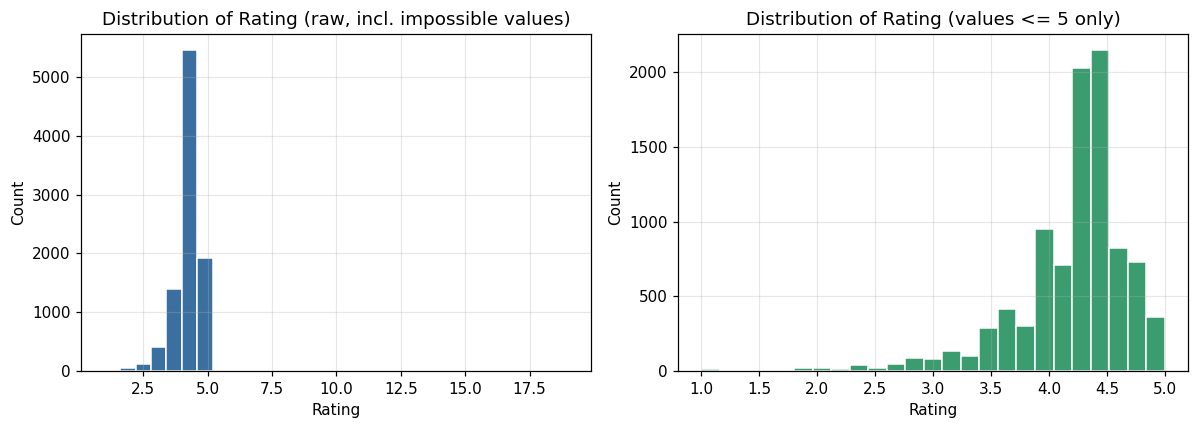

Saved: ../figures/01_rating_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_raw["Rating"].dropna(), bins=30, color="#3b6fa0", edgecolor="white")
axes[0].set_title("Distribution of Rating (raw, incl. impossible values)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

valid_ratings = df_raw.loc[df_raw["Rating"] <= 5, "Rating"].dropna()
axes[1].hist(valid_ratings, bins=25, color="#3b9c6f", edgecolor="white")
axes[1].set_title("Distribution of Rating (values <= 5 only)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_rating_distribution.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/01_rating_distribution.png")


**Observation.** The raw `Rating` distribution is strongly left-skewed:
most apps sit between roughly 4.0 and 4.5 stars, with a long, sparse tail down to 1.0.
This matters for modelling because (a) the target is not symmetric or normally
distributed, and (b) a large majority of the mass is concentrated in a narrow band,
which limits how much variance any model can realistically explain — consistent with
the faculty's expected R² of 0.05–0.15.


## 5. Missing-Value Audit (All Columns)


In [9]:
missing_table = pd.DataFrame({
    "n_missing": df_raw.isnull().sum(),
    "pct_missing": (df_raw.isnull().mean() * 100).round(2),
}).sort_values("n_missing", ascending=False)
missing_table


,n_missing,pct_missing
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01
Size,0,0.00
Reviews,0,0.00
Category,0,0.00
App,0,0.00
Price,0,0.00


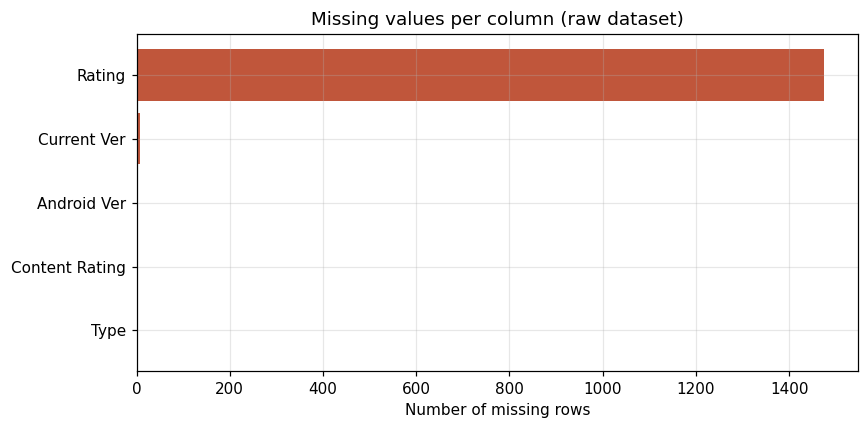

Saved: ../figures/02_missing_values.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_nonzero = missing_table[missing_table["n_missing"] > 0]
ax.barh(missing_nonzero.index[::-1], missing_nonzero["n_missing"][::-1], color="#c0563b")
ax.set_xlabel("Number of missing rows")
ax.set_title("Missing values per column (raw dataset)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_missing_values.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/02_missing_values.png")


**Observation.** `Rating` is by far the column with the most missing values
(roughly 13-14% of rows), which is expected: not every listed app has received
enough reviews to be assigned a rating. `Type`, `Content Rating`, `Current Ver`, and
`Android Ver` have only a handful of missing values each. Because `Rating` is the
target variable, rows with a missing target cannot be used for supervised training
and will be excluded before modelling (documented in `02_preprocessing.ipynb`); they
are *not* dropped here, since this notebook is audit-only.


## 6. Duplicate `App` Name Audit


In [11]:
n_total_rows = df_raw.shape[0]
n_unique_apps = df_raw["App"].nunique()
n_duplicated_rows = df_raw.duplicated(subset=["App"]).sum()
n_rows_in_dup_groups = df_raw[df_raw.duplicated(subset=["App"], keep=False)].shape[0]

print(f"Total rows:                              {n_total_rows}")
print(f"Unique App names:                        {n_unique_apps}")
print(f"Rows that are duplicate copies (extra):   {n_duplicated_rows}")
print(f"Rows belonging to any duplicated App:     {n_rows_in_dup_groups}")


Total rows:                              10841
Unique App names:                        9660
Rows that are duplicate copies (extra):   1181
Rows belonging to any duplicated App:     1979


In [12]:
app_counts = df_raw["App"].value_counts()
top_duplicated_apps = app_counts[app_counts > 1].head(10)
top_duplicated_apps


App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
8 Ball Pool                                          7
ESPN                                                 7
Nick                                                 6
Subway Surfers                                       6
Bubble Shooter                                       6
slither.io                                           6
Name: count, dtype: int64

In [13]:
# Concrete example: the single most-duplicated App name
example_app = app_counts.index[0]
print(f"Example — '{example_app}' appears {app_counts.iloc[0]} times:")
df_raw[df_raw["App"] == example_app]


Example — 'ROBLOX' appears 9 times:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1653,ROBLOX,GAME,4.5,4447388,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1701,ROBLOX,GAME,4.5,4447346,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1748,ROBLOX,GAME,4.5,4448791,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1841,ROBLOX,GAME,4.5,4449882,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1870,ROBLOX,GAME,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2016,ROBLOX,FAMILY,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2088,ROBLOX,FAMILY,4.5,4450855,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2206,ROBLOX,FAMILY,4.5,4450890,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
4527,ROBLOX,FAMILY,4.5,4443407,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up


**Observation.** The dataset contains many exact and near-exact duplicate rows
for the same `App` name (e.g. the example above). Duplicate rows for the same app
typically differ only in the `Reviews` count and occasionally in `Category`,
suggesting the data was scraped from the Play Store at different points in time
without full deduplication upstream. Per the faculty's instruction, these will be
deduplicated **on `App` name** in preprocessing (keeping one representative row per
app, e.g. the one with the highest review count), and the row counts before/after
will be reported in the Section 2.5 table of the final report.


## 7. The Known Malformed / Shifted Row

The faculty flagged a specific row where the column values are shifted by one
position (this is a well-documented issue in this Kaggle dataset). It is detected
below using the fact that `Rating` can only legitimately range from 1.0 to 5.0 — a
`Rating` value above 5 is structurally impossible and is the fingerprint of the
shift.


In [14]:
malformed = df_raw[df_raw["Rating"] > 5]
print(f"Rows with an impossible Rating value (> 5.0): {malformed.shape[0]}")
malformed


Rows with an impossible Rating value (> 5.0): 1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [15]:
row_idx = malformed.index[0]
print(f"Malformed row index: {row_idx}")
print()
print("Raw values in this row, column by column:")
for col in df_raw.columns:
    print(f"  {col:16s} -> {df_raw.loc[row_idx, col]!r}")


Malformed row index: 10472

Raw values in this row, column by column:
  App              -> 'Life Made WI-Fi Touchscreen Photo Frame'
  Category         -> '1.9'
  Rating           -> np.float64(19.0)
  Reviews          -> '3.0M'
  Size             -> '1,000+'
  Installs         -> 'Free'
  Type             -> '0'
  Price            -> 'Everyone'
  Content Rating   -> nan
  Genres           -> 'February 11, 2018'
  Last Updated     -> '1.0.19'
  Current Ver      -> '4.0 and up'
  Android Ver      -> nan


**Why this row is malformed.** Reading the values against what each column is
supposed to contain shows a one-position left shift starting at `Category`:

- `Category` holds `'1.9'` — a version-like number, not a category name.
- `Rating` holds `19.0` — impossible on a 1–5 scale (this is actually a `Reviews`
  count that slid into the `Rating` slot).
- `Reviews` holds `'3.0M'` — a size string, not a review count.
- `Size` holds `'1,000+'` — an installs string, not a size.
- `Installs` holds `'Free'` — a type string, not an installs count.
- `Type` holds `'0'` — a price string, not Free/Paid.
- `Price` holds `'Everyone'` — a content-rating string, not a price.
- `Content Rating` is `NaN`, and `Genres` holds a date (`'February 11, 2018'`).

This is consistent with the app's true `Category` value being missing/blank in the
original scrape, which shifted every subsequent field one column to the left. This
single row (App: *"Life Made WI-Fi Touchscreen Photo Frame"*, index `10472`) is kept
visible here for audit purposes and will be **corrected or removed** (not silently
dropped) in `02_preprocessing.ipynb`, with the decision and reasoning documented
there and in report Section 2.1.


## 8. Other Impossible / Suspicious Values


In [16]:
# Reviews should be a numeric string for every row except the known malformed row
non_numeric_reviews = df_raw[~df_raw["Reviews"].str.match(r"^\d+$", na=False)]
print("Rows where 'Reviews' is not a plain integer string:")
non_numeric_reviews[["App", "Reviews"]]


Rows where 'Reviews' is not a plain integer string:


,App,Reviews
10472,Life Made WI-Fi Touchscreen Photo Frame,3.0M


In [17]:
# Installs contains a literal '0' and '0+' for some rows; confirm these are
# legitimate zero-install listings rather than parsing errors.
zero_installs = df_raw[df_raw["Installs"].isin(["0", "0+"])]
print(f"Rows with Installs == '0' or '0+': {zero_installs.shape[0]}")
zero_installs[["App", "Installs", "Type", "Rating"]]


Rows with Installs == '0' or '0+': 15


,App,Installs,Type,Rating
4465,Popsicle Launcher for Android P 9.0 launcher,0+,Paid,NaN
5307,Ak Parti Yardım Toplama,0+,Paid,NaN
5486,AP Series Solution Pro,0+,Paid,NaN
5945,Ain Arabic Kids Alif Ba ta,0+,Paid,NaN
6692,cronometra-br,0+,Paid,NaN
7434,Pekalongan CJ,0+,Free,NaN
8081,CX Network,0+,Free,NaN
8614,Sweden Newspapers,0+,Free,NaN
8871,Test Application DT 02,0+,Free,NaN
9148,Command & Conquer: Rivals,0,NaN,NaN


In [18]:
# Type should only ever be 'Free' or 'Paid'
print("Unique values in 'Type':", df_raw["Type"].unique())
df_raw[df_raw["Type"].isin([None, "0"]) | df_raw["Type"].isnull()][["App","Type","Installs","Price"]]


Unique values in 'Type': <StringArray>
['Free', 'Paid', nan, '0']
Length: 4, dtype: str


,App,Type,Installs,Price
9148,Command & Conquer: Rivals,NaN,0,0
10472,Life Made WI-Fi Touchscreen Photo Frame,0,Free,Everyone


**Observation.** Aside from the single malformed row identified in Section 7,
`Reviews` is a clean integer-like string for every other row. The `Installs`
values of `'0'`/`'0+'` (15 apps) and the single `Type` value of `'0'` are both
artefacts: the `'0'` `Type` belongs to the row *"Command & Conquer: Rivals"*, whose
`Installs` is also the bare string `'0'` (missing the `+`), suggesting this app was
freshly listed with no installs yet and an unpopulated `Type` field, and the `Type`
value `'0'` on the malformed row is the shifted `Price` field described in Section 7.
These are documented here so that the parsing rules written in preprocessing account
for them explicitly rather than silently coercing them to `NaN`.


## 9. Inconsistent Categorical Values


In [19]:
print("Category — n_unique:", df_raw["Category"].nunique())
print(sorted(df_raw["Category"].unique()))


Category — n_unique: 34
['1.9', 'ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY', 'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION', 'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FAMILY', 'FINANCE', 'FOOD_AND_DRINK', 'GAME', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'MAPS_AND_NAVIGATION', 'MEDICAL', 'NEWS_AND_MAGAZINES', 'PARENTING', 'PERSONALIZATION', 'PHOTOGRAPHY', 'PRODUCTIVITY', 'SHOPPING', 'SOCIAL', 'SPORTS', 'TOOLS', 'TRAVEL_AND_LOCAL', 'VIDEO_PLAYERS', 'WEATHER']


`Category` contains 34 distinct values, all upper-case with underscores, **except
`'1.9'`**, which is the fingerprint of the malformed row identified in Section 7 (a
category can never legitimately be a decimal number). No other inconsistent casing
or spelling variants were found in `Category`.


In [20]:
print("Content Rating — unique values:")
print(df_raw["Content Rating"].unique())
print()
print("Type — unique values:")
print(df_raw["Type"].unique())


Content Rating — unique values:
<StringArray>
['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+', 'Unrated', nan]
Length: 7, dtype: str

Type — unique values:
<StringArray>
['Free', 'Paid', nan, '0']
Length: 4, dtype: str


In [21]:
print("Genres — n_unique:", df_raw["Genres"].nunique())
df_raw["Genres"].value_counts().head(10)


Genres — n_unique: 120


Genres
Tools              842
Entertainment      623
Education          549
Medical            463
Business           460
Productivity       424
Sports             398
Personalization    392
Communication      387
Lifestyle          381
Name: count, dtype: int64

**Observation.** `Content Rating` and `Type` are clean and low-cardinality
(aside from the shifted-row artefacts already noted). `Genres` is high-cardinality
(120 distinct values) and many values are compound (e.g. `"Adventure;Action &
Adventure"`), effectively encoding a primary genre plus an `Category`-like tag joined
by `;`. This is noted for feature-engineering: `Genres` largely duplicates
`Category` information at a finer grain and may not need its own encoding if
`Category` is already used, to avoid redundant/high-cardinality one-hot columns.


## 10. Raw Descriptive Analysis (Numeric and Categorical)

`Rating` is the only column pandas already treats as numeric. The other numeric-in-
spirit columns (`Reviews`, `Size`, `Installs`, `Price`) are still raw strings at this
point, so only `Rating` can be described numerically here; the others are examined
as categorical/text distributions instead. Full numeric parsing happens in
`02_preprocessing.ipynb`.


In [22]:
print("Rating (valid range only, <= 5.0):")
print(df_raw.loc[df_raw["Rating"] <= 5, "Rating"].describe())


Rating (valid range only, <= 5.0):
count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [23]:
cat_summary = pd.DataFrame({
    "column": ["Category", "Type", "Content Rating", "Genres"],
    "n_unique": [df_raw[c].nunique() for c in ["Category", "Type", "Content Rating", "Genres"]],
    "most_common_value": [df_raw[c].mode().iloc[0] for c in ["Category", "Type", "Content Rating", "Genres"]],
    "most_common_share_pct": [
        round((df_raw[c].value_counts(normalize=True).iloc[0]) * 100, 1)
        for c in ["Category", "Type", "Content Rating", "Genres"]
    ],
})
cat_summary


,column,n_unique,most_common_value,most_common_share_pct
0,Category,34,FAMILY,18.2
1,Type,3,Free,92.6
2,Content Rating,6,Everyone,80.4
3,Genres,120,Tools,7.8


In [24]:
df_raw["Category"].value_counts().head(10)


Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382
Name: count, dtype: int64

**Observation.** `GAME` and `FAMILY` are the two largest app categories by a
wide margin. `Type` is dominated by `Free` apps (the large majority of the
dataset), and `Content Rating` is dominated by `Everyone`. This class imbalance in
`Type` (Free vs Paid) is relevant later: with very few paid apps, any `is_paid`
feature will have low variance and limited statistical power.


## 11. Exploratory Visualisations


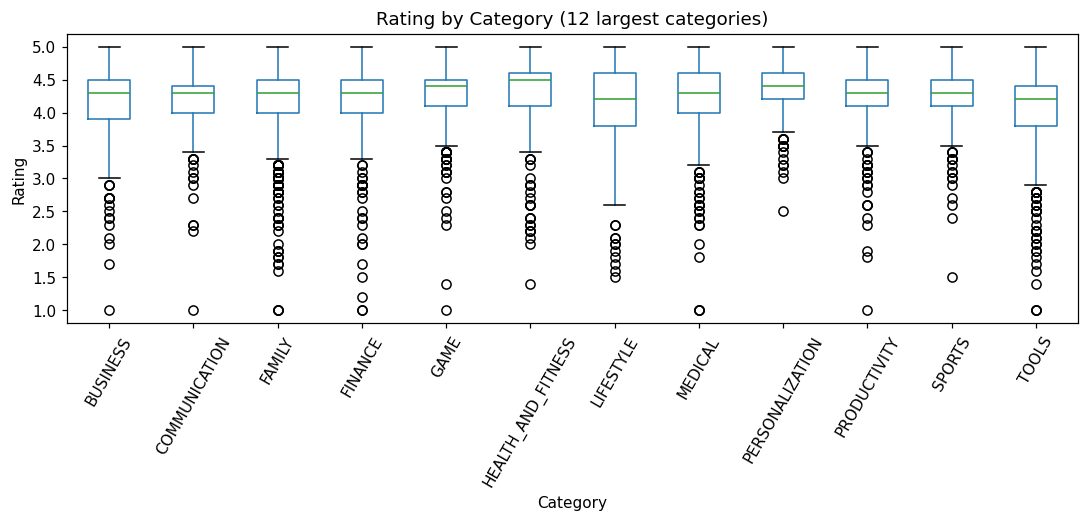

Saved: ../figures/03_rating_by_category.png


In [25]:
top_categories = df_raw["Category"].value_counts().head(12).index
subset = df_raw[df_raw["Category"].isin(top_categories) & (df_raw["Rating"] <= 5)]

fig, ax = plt.subplots(figsize=(10, 5))
order = subset.groupby("Category")["Rating"].median().sort_values(ascending=False).index
subset.boxplot(column="Rating", by="Category", ax=ax, rot=60, grid=False)
ax.set_title("Rating by Category (12 largest categories)")
plt.suptitle("")
ax.set_xlabel("Category")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_rating_by_category.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/03_rating_by_category.png")


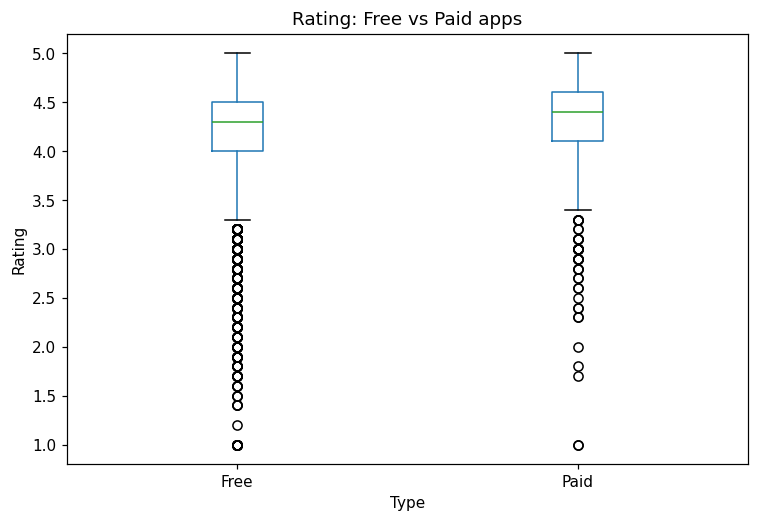

Saved: ../figures/04_rating_free_vs_paid.png

       count      mean       std
Type                            
Free  8719.0  4.186203  0.512338
Paid   647.0  4.266615  0.547523


In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
free_vs_paid = df_raw[df_raw["Rating"] <= 5].dropna(subset=["Rating", "Type"])
free_vs_paid = free_vs_paid[free_vs_paid["Type"].isin(["Free", "Paid"])]
free_vs_paid.boxplot(column="Rating", by="Type", ax=ax, grid=False)
ax.set_title("Rating: Free vs Paid apps")
plt.suptitle("")
ax.set_xlabel("Type")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_rating_free_vs_paid.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/04_rating_free_vs_paid.png")

print()
print(free_vs_paid.groupby("Type")["Rating"].describe()[["count", "mean", "std"]])


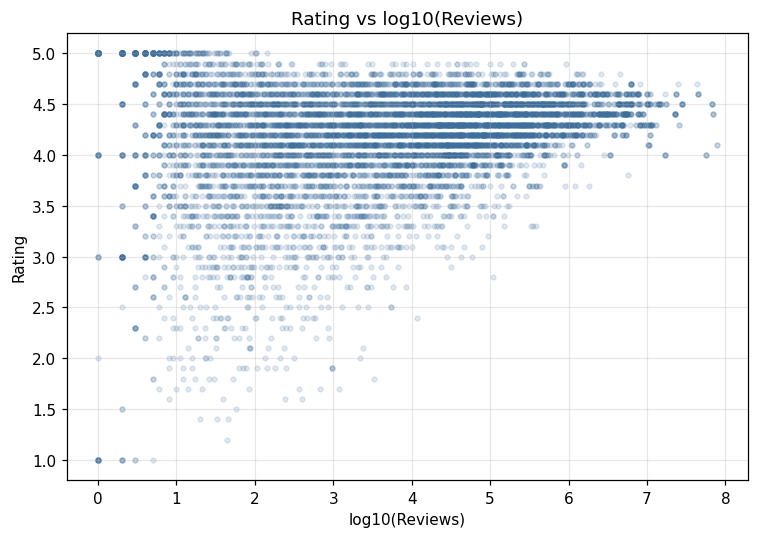

Saved: ../figures/05_rating_vs_log_reviews.png
Pearson correlation, log10(Reviews) vs Rating: 0.2098


In [27]:
# Reviews (log scale, valid numeric rows only) vs Rating
reviews_numeric = pd.to_numeric(
    df_raw.loc[df_raw["Rating"] <= 5, "Reviews"], errors="coerce"
)
plot_df = pd.DataFrame({
    "Reviews": reviews_numeric,
    "Rating": df_raw.loc[df_raw["Rating"] <= 5, "Rating"],
}).dropna()
plot_df = plot_df[plot_df["Reviews"] > 0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log10(plot_df["Reviews"]), plot_df["Rating"], alpha=0.15, s=10, color="#3b6fa0")
ax.set_xlabel("log10(Reviews)")
ax.set_ylabel("Rating")
ax.set_title("Rating vs log10(Reviews)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_rating_vs_log_reviews.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/05_rating_vs_log_reviews.png")

corr = np.corrcoef(np.log10(plot_df["Reviews"]), plot_df["Rating"])[0, 1]
print(f"Pearson correlation, log10(Reviews) vs Rating: {corr:.4f}")


**Observations from the visualisations.**

- Median `Rating` varies only mildly across the 12 largest categories — most medians
  sit close to 4.2–4.5 — suggesting `Category` carries some, but not dominant, signal.
- Paid apps show a slightly higher mean `Rating` than Free apps in this raw view, but
  the paid-app sample is much smaller, so this difference should be treated
  cautiously and re-checked with proper statistics in `03` / Section 3 of the report.
- `log10(Reviews)` shows only a weak positive linear relationship with `Rating` — the
  scatter is very diffuse. This is an early, direct signal supporting the faculty's
  expectation of a low R² (~0.05–0.15): even the variable most likely to correlate
  with `Rating` shows a weak, noisy relationship.


## 12. Preliminary Observations Relevant to Modelling

These observations, grounded in the evidence above, will drive the preprocessing
and feature-engineering decisions in later notebooks:

1. **Weak raw signal.** Even the most plausible predictor (`Reviews`, log-scaled)
   shows only a weak correlation with `Rating`. This is consistent with the
   faculty's guidance that R² in the 0.05–0.15 range should be expected and is
   acceptable if reported honestly.
2. **Target has missing values and a skewed distribution.** ~13-14% of rows have no
   `Rating`; these rows cannot be used for supervised training and must be dropped
   before modelling (not before, so as not to contaminate the audit). The valid
   ratings are concentrated between 4.0 and 4.5, which limits achievable variance
   explained.
3. **One malformed row must be corrected, not silently dropped.** Row index `10472`
   has all fields shifted one column left due to a missing `Category` value at
   source; it will be explicitly corrected or removed with justification in
   `02_preprocessing.ipynb`.
4. **Duplicate `App` rows must be deduplicated.** Many apps have multiple rows that
   differ mainly in `Reviews`; the dataset will be deduplicated on `App`, keeping the
   most information-rich row (e.g., highest `Reviews`), consistent with the faculty
   instruction.
5. **Several columns require explicit string parsing before they are usable
   numerically**: `Reviews` (strip and cast to int), `Size` (convert `M`/`k` suffixes
   to MB, and decide a treatment for `'Varies with device'`), `Installs` (strip
   commas and `+`), and `Price` (strip `$` and cast to float). All four are stored as
   text in the raw file and are unusable as numeric model inputs until parsed.
6. **`Genres` is high-cardinality and overlaps with `Category`.** Encoding both as
   separate one-hot feature blocks would risk redundant, high-dimensional features
   for little added signal; this trade-off will be revisited in feature selection.
7. **`Type` (Free/Paid) is heavily imbalanced.** The very small number of paid apps
   limits how much statistical power any `is_paid`-derived feature can have.
